# Task 1 - Load and visualize the dataset

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

mat_path = 'ex7data2.mat'
data = loadmat(mat_path)
X = data['X']
print('Shape of X:', X.shape)
print('First 5 rows of X:\n', X[:5])


Shape of X: (300, 2)
First 5 rows of X:
 [[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]


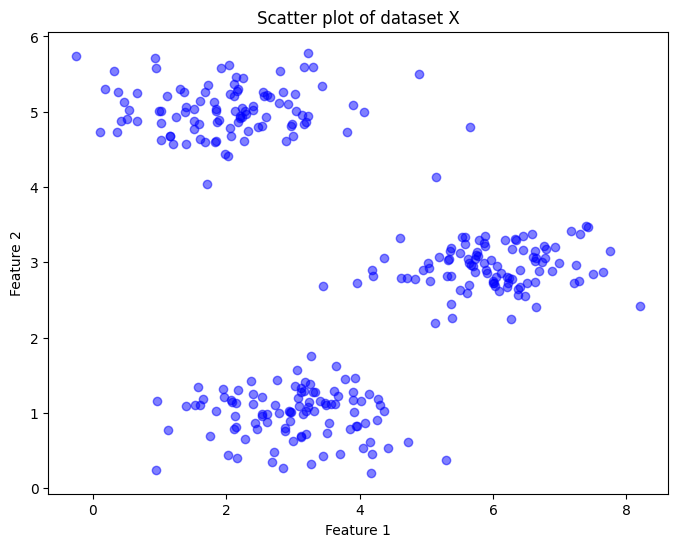

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c='blue', alpha=0.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter plot of dataset X')
plt.show()

# Task 2 - Finding closest centroids

In [11]:
def find_closest_centroids(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    idx = np.argmin(distances, axis=1)
    return idx

initial_centroids = np.array([[3, 3], [6, 2], [8, 5]], dtype=float)
idx = find_closest_centroids(X, initial_centroids)
print('Closest centroids for the first 3 examples:', idx[:3])

Closest centroids for the first 3 examples: [0 2 1]


# Task 3 - Computing centroids

In [13]:
def compute_centroids(X, idx, K, rng=None):
    m, n = X.shape
    new_centroids = np.zeros((K, n), dtype=float)
    rng = np.random.default_rng() if rng is None else rng
    for k in range(K):
        points_assigned = X[idx == k]
        if len(points_assigned) > 0:
            new_centroids[k] = np.mean(points_assigned, axis=0)
        else:
            new_centroids[k] = X[rng.integers(0, m)]
    return new_centroids

idx_test = find_closest_centroids(X, initial_centroids)
print('Closest centroids for the first 3 examples (test):', idx_test[:3])

Closest centroids for the first 3 examples (test): [0 2 1]


# Task 4 - Running K-means

Final centroids after K-Means:
 [[1.95399466 5.02557006]
 [3.04367119 1.01541041]
 [6.03366736 3.00052511]]


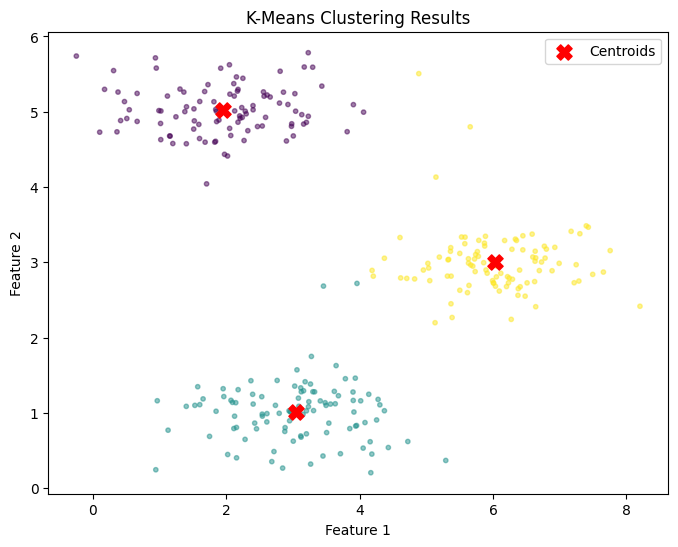

In [17]:
def run_k_means(X, init_centroids, max_iters=10, rng=None):
    K = init_centroids.shape[0]
    centroids = init_centroids.copy().astype(float)
    history = [centroids.copy()]
    idx = None
    for it in range(max_iters):
        idx = find_closest_centroids(X, centroids)
        centroids = compute_centroids(X, idx, K, rng)
        history.append(centroids.copy())
    return centroids, idx, history

final_centroids, final_idx, history = run_k_means(X, initial_centroids, max_iters=10)
print('Final centroids after K-Means:\n', final_centroids)
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=final_idx, s=10,  cmap='viridis', alpha=0.5)
plt.scatter(final_centroids[:,0], final_centroids[:,1], c='red', marker='X', s=120, label='Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering Results')
plt.legend()
plt.show()

# Task 5 - Initializing centroids

In [18]:
def init_centroids(X, K, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    m = X.shape[0]
    random_indices = rng.choice(m, size=K, replace=False)
    centroids = X[random_indices]
    return centroids
    raise NotImplentedError
K = 3
rng = np.random.default_rng(42) 
centroids = init_centroids(X, K, rng)
print('Initialized centroids:\n', centroids)


Initialized centroids:
 [[5.29239452 0.36873298]
 [2.85962615 5.26041997]
 [5.73284945 2.87738132]]


# Task 6 - Multiple initializations and evaluation

In [20]:
def withinss(X, centroids, idx):
    diffs = X - centroids[idx]
    return float(np.sum(diffs * diffs))
best = {'score': np.inf}
for seed in range(5):
    rng = np.random.default_rng(seed)
    c0 = init_centroids(X, 3, rng)
    cF, idxF, hist = run_k_means(X, c0, max_iters=10, rng=rng)
    s = withinss(X, cF, idxF)
    if s < best['score']:
         best = {'score': s, 'centroids': cF, 'idx': idxF}
print('Best inertia:', best['score'])

Best inertia: 266.65851965491936


In [21]:
import pandas as pd
rep = pd.DataFrame({'x1': X[:,0], 'x2': X[:,1], 'cluster': best['idx']})
rep.to_csv('kmeans_assignments.csv', index=False)
print('Wrote kmeans_assignments.csv')

Wrote kmeans_assignments.csv
